In [1]:
from pathlib import Path

import jupyter_black
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import cohen_kappa_score

# Use verbose pandas mode
pd.options.display.max_rows = 200

load_dotenv()
jupyter_black.load()

In [ ]:
data_path = Path("/workspace/data/llmPredictions")
df_all = pd.read_csv(data_path / "merged_sdgs_predictions.csv")

# Confirm integrity
print(
    f"Loaded merged dataset: {df_all.shape[0]} rows, {df_all['DOI'].nunique()} unique DOIs"
)
print(
    df_all[
        [
            "DOI",
            "SDG",
            "Model",
            "model_label",
        ]
    ].head()
)

Loaded merged dataset: 93510 rows, 46572 unique DOIs
                             DOI   SDG Model   model_label
0             10.1093/sp/jxab007  SDG1  Qwen  Non-Relevant
1             10.1111/jomf.12987  SDG1  Qwen  Non-Relevant
2      10.1177/14733250231225170  SDG1  Qwen      Relevant
3     10.1016/j.eswa.2024.123680  SDG1  Qwen  Non-Relevant
4  10.1080/14616696.2020.1869283  SDG1  Qwen      Relevant


Index(['DOI', 'Abstract', 'SDG', 'Model', 'model_label'], dtype='object')

## Compute Model Agreement

In [5]:
# Pivot dataset to compare model labels for the same abstract
df_pivot = df_all.pivot_table(
    index=["DOI", "Abstract", "SDG"],
    columns="Model",
    values="model_label",
    aggfunc="first",
).reset_index()

# Flatten column index if needed
df_pivot.columns.name = None
df_pivot.columns = [str(col) for col in df_pivot.columns]

# Drop rows where either model is missing a label
df_pivot.dropna(subset=["Llama", "Qwen"], inplace=True)

In [6]:
# Compute agreement statistics
total_samples = len(df_pivot)
matching_labels = (df_pivot["Llama"] == df_pivot["Qwen"]).sum()
agreement_rate = matching_labels / total_samples
kappa_score = cohen_kappa_score(df_pivot["Llama"], df_pivot["Qwen"])

print(f"Total abstracts compared: {total_samples}")
print(f"Model agreement rate: {agreement_rate:.2%}")
print(f"Cohen’s Kappa Score: {kappa_score:.3f}")


for sdg in df_pivot["SDG"].unique():
    subset = df_pivot[df_pivot["SDG"] == sdg]
    total = len(subset)
    match = (subset["Llama"] == subset["Qwen"]).sum()
    kappa = cohen_kappa_score(subset["Llama"], subset["Qwen"])
    print(f"{sdg}: Agreement = {match / total:.2%}, Kappa = {kappa:.3f} (n={total})")

Total abstracts compared: 46755
Model agreement rate: 83.56%
Cohen’s Kappa Score: 0.467
SDG1: Agreement = 81.75%, Kappa = 0.506 (n=15133)
SDG3: Agreement = 89.63%, Kappa = 0.398 (n=15674)
SDG7: Agreement = 79.31%, Kappa = 0.428 (n=15948)


### Model Agreement Summary

The merged dataset contained 46,755 abstracts evaluated by both **LLaMA 3.1** and **Qwen** across **SDG 1**, **SDG 3**, and **SDG 7**.  
The table and commentary below summarize the global and per-SDG agreement results.


#### Overall Agreement

| Metric | Value | Interpretation |
|---------|--------|----------------|
| **Total abstracts compared** | 46,755 | Number of document–SDG pairs for which both models provided a label |
| **Agreement rate** | **83.56 %** | About four in five judgments are identical (“Relevant” / “Not Relevant”) |
| **Cohen’s κ** | **0.467** | Indicates *moderate* agreement — well above chance but leaving substantial structured divergence |

A κ of ≈ 0.47 represents moderate inter-model consistency.  
This level is high enough to demonstrate comparable behavior across models yet low enough to permit meaningful disagreement analysis, which is the focus of subsequent sections.


#### Agreement by SDG

| SDG | Agreement | κ | n | Observations |
|-----|------------|---|---|---------------|
| **SDG 1 (No Poverty)** | **81.75 %** | **0.506** | 15,133 | Highest κ; judgments align closely for socio-economic abstracts, suggesting fewer ambiguous “analytical vs. intervention” cases. |
| **SDG 3 (Good Health and Well-Being)** | **89.63 %** | **0.398** | 15,674 | High raw agreement but lower κ, reflecting class imbalance (many Non-Relevant labels). |
| **SDG 7 (Affordable and Clean Energy)** | **79.31 %** | **0.428** | 15,948 | Broader topical variation; greater asymmetry in how models interpret energy-related relevance. |


#### Interpretation

- The **global κ = 0.467** indicates **moderate agreement** overall.  
- **SDG 3** exhibits the highest raw agreement but a low κ, implying strong label skew toward Non-Relevant.  
- **SDG 7** shows greater lexical heterogeneity and thus lower alignment.  
- **SDG 1** presents the most balanced and semantically interpretable divergence between the two models.

In [7]:
# Count exact agreement cases by label type
both_relevant = (
    (df_pivot["Llama"] == "Relevant") & (df_pivot["Qwen"] == "Relevant")
).sum()
both_nonrelevant = (
    (df_pivot["Llama"] == "Non-Relevant") & (df_pivot["Qwen"] == "Non-Relevant")
).sum()
disagree = total_samples - matching_labels

print(
    f"Both models labeled Relevant: {both_relevant} ({both_relevant / total_samples:.2%})"
)
print(
    f"Both models labeled Non-Relevant: {both_nonrelevant} ({both_nonrelevant / total_samples:.2%})"
)
print(f"Disagreement cases: {disagree} ({disagree / total_samples:.2%})")

Both models labeled Relevant: 34019 (72.76%)
Both models labeled Non-Relevant: 5050 (10.80%)
Disagreement cases: 7686 (16.44%)


### Agreement Composition by Label Type

| Category | Count | Proportion | Interpretation |
|-----------|--------|-------------|----------------|
| **Both Relevant** | 34,019 | **72.76 %** | The majority of agreements are positive judgments where both models identify the abstract as contributing to its SDG. |
| **Both Non-Relevant** | 5,050 | **10.80 %** | A much smaller fraction of abstracts are jointly excluded. |
| **Disagreement** | 7,686 | **16.44 %** | Roughly one in six cases shows divergent model labeling. |

### Observations

The results align with expectations given the retrieval source:  
all abstracts originated from Boolean SDG queries, which were designed to maximize recall rather than precision.  
Accordingly, most abstracts are indeed labeled **Relevant** by both models (≈73%), confirming that the query pools contain a high proportion of positive cases.

What is more informative is the **relative size of disagreement (16.4%) compared to shared Non-Relevant cases (10.8%)**.  
This means that when one model excludes a document, the other often includes it—divergence is more common than mutual rejection.

Such a pattern suggests that model disagreement is not driven by random error or uniformly conservative thresholds, but by **differences in how each model interprets marginal or context-dependent relevance** within the same semantic field.  
In other words, the two models are drawing different boundaries around what constitutes a “contribution” to the SDG rather than jointly underpredicting relevance.


In [8]:
for sdg in df_pivot["SDG"].unique():
    subset = df_pivot[df_pivot["SDG"] == sdg]
    total = len(subset)
    match = (subset["Llama"] == subset["Qwen"]).sum()
    kappa = cohen_kappa_score(subset["Llama"], subset["Qwen"])

    both_rel = ((subset["Llama"] == "Relevant") & (subset["Qwen"] == "Relevant")).sum()
    both_nonrel = (
        (subset["Llama"] == "Non-Relevant") & (subset["Qwen"] == "Non-Relevant")
    ).sum()

    print(f"{sdg}: Agreement = {match / total:.2%}, Kappa = {kappa:.3f} (n={total})")
    print(f"    Both Relevant: {both_rel} ({both_rel / total:.2%})")
    print(f"    Both Non-Relevant: {both_nonrel} ({both_nonrel / total:.2%})")
    print(f"    Disagreement: {total - match} ({(total - match) / total:.2%})")

SDG1: Agreement = 81.75%, Kappa = 0.506 (n=15133)
    Both Relevant: 10051 (66.42%)
    Both Non-Relevant: 2320 (15.33%)
    Disagreement: 2762 (18.25%)
SDG3: Agreement = 89.63%, Kappa = 0.398 (n=15674)
    Both Relevant: 13370 (85.30%)
    Both Non-Relevant: 679 (4.33%)
    Disagreement: 1625 (10.37%)
SDG7: Agreement = 79.31%, Kappa = 0.428 (n=15948)
    Both Relevant: 10598 (66.45%)
    Both Non-Relevant: 2051 (12.86%)
    Disagreement: 3299 (20.69%)


### Agreement Composition by SDG

| SDG | Agreement | κ | n | Both Relevant | Both Non-Relevant | Disagreement |
|-----|------------|---|---|---------------|-------------------|---------------|
| **SDG 1 (No Poverty)** | 81.75 % | 0.506 | 15 133 | 66.42 % | 15.33 % | 18.25 % |
| **SDG 3 (Good Health and Well-Being)** | 89.63 % | 0.398 | 15 674 | 85.30 % | 4.33 % | 10.37 % |
| **SDG 7 (Affordable and Clean Energy)** | 79.31 % | 0.428 | 15 948 | 66.45 % | 12.86 % | 20.69 % |

#### Interpretation

- **High agreement across SDGs**: 82--90% of cases receive identical relevance labels from both models.  
  Cohen’s κ values between 0.40–0.51 indicate *moderate* agreement once chance is taken into account.

- **Positive-label dominance**: In every SDG, most agreements are *Relevant* rather than *Non-Relevant*.  
  This is expected because all abstracts were retrieved using SDG-targeted Boolean queries, which strongly bias the pool toward true positives.

- **Disagreement exceeds shared Non-Relevance** for **SDG 1** and **SDG 7**.  
  In these domains, divergence (≈ 18--21%) outnumbers mutual exclusion (≈ 13--15%).  
  That pattern suggests that model differences stem from how each interprets marginal or context-dependent relevance, not from one model being uniformly stricter.

- **SDG 3** shows a different balance: high raw agreement (≈ 90 %) and very few shared Non-Relevant cases (4 %).  
  Non-Relevance is *rarely mutual*; it is usually model-specific.  
  Each model excludes a somewhat different subset of abstracts, suggesting distinct semantic thresholds for what constitutes a health contribution.



In [9]:
for sdg in df_pivot["SDG"].unique():
    subset = df_pivot[df_pivot["SDG"] == sdg]
    total = len(subset)

    # core stats you already print
    match = (subset["Llama"] == subset["Qwen"]).sum()
    kappa = cohen_kappa_score(subset["Llama"], subset["Qwen"])
    both_rel = ((subset["Llama"] == "Relevant") & (subset["Qwen"] == "Relevant")).sum()
    both_non = (
        (subset["Llama"] == "Non-Relevant") & (subset["Qwen"] == "Non-Relevant")
    ).sum()
    disagree = total - match

    # --- NEW 1: direction of disagreement  ------------------------
    llama_only = (
        (subset["Llama"] == "Relevant") & (subset["Qwen"] == "Non-Relevant")
    ).sum()
    qwen_only = (
        (subset["Llama"] == "Non-Relevant") & (subset["Qwen"] == "Relevant")
    ).sum()

    liberal_ratio = (
        llama_only / disagree if disagree else 0
    )  # >0.5 => Llama more liberal

    # --- NEW 2: prevalence & bias indices (PABAK) ----------------
    prevalence = abs(
        (subset["Llama"] == "Relevant").mean() - (subset["Qwen"] == "Relevant").mean()
    )
    bias = abs(llama_only - qwen_only) / total
    pabak = (match / total) - prevalence  # simple form; full PABAK adds +1 then /2

    # --- NEW 3: quick confusion matrix ---------------------------
    #  (optional to print, but handy for sanity checks)
    conf = pd.crosstab(subset["Llama"], subset["Qwen"])

    # ---- PRINT ---------------------------------------------------
    print(f"{sdg}: Agreement {match/total:.2%}, κ={kappa:.3f}, n={total}")
    print(f"  Both Rel  : {both_rel:5} ({both_rel/total:.2%})")
    print(f"  Both Non  : {both_non:5} ({both_non/total:.2%})")
    print(f"  Disagree  : {disagree:5} ({disagree/total:.2%})")
    print(
        f"    Llama only rel: {llama_only:4}  | Qwen only rel: {qwen_only:4} "
        f"| liberal_ratio={liberal_ratio:.2f}"
    )
    print(f"  Prevalence idx={prevalence:.3f}, Bias idx={bias:.3f}, PABAK≈{pabak:.3f}")
    print(conf, "\n")

SDG1: Agreement 81.75%, κ=0.506, n=15133
  Both Rel  : 10051 (66.42%)
  Both Non  :  2320 (15.33%)
  Disagree  :  2762 (18.25%)
    Llama only rel: 1318  | Qwen only rel: 1444 | liberal_ratio=0.48
  Prevalence idx=0.008, Bias idx=0.008, PABAK≈0.809
Qwen          Non-Relevant  Relevant
Llama                               
Non-Relevant          2320      1444
Relevant              1318     10051 

SDG3: Agreement 89.63%, κ=0.398, n=15674
  Both Rel  : 13370 (85.30%)
  Both Non  :   679 (4.33%)
  Disagree  :  1625 (10.37%)
    Llama only rel:  762  | Qwen only rel:  863 | liberal_ratio=0.47
  Prevalence idx=0.006, Bias idx=0.006, PABAK≈0.890
Qwen          Non-Relevant  Relevant
Llama                               
Non-Relevant           679       863
Relevant               762     13370 

SDG7: Agreement 79.31%, κ=0.428, n=15948
  Both Rel  : 10598 (66.45%)
  Both Non  :  2051 (12.86%)
  Disagree  :  3299 (20.69%)
    Llama only rel: 2464  | Qwen only rel:  835 | liberal_ratio=0.75
  Prev

### Directional and Bias Analysis of Model Disagreement

| SDG | Agreement | κ | n | Both Relevant | Both Non-Relevant | Disagreement | LLaMA-only Relevant | Qwen-only Relevant | Liberal Ratio (LLaMA>Qwen) | Prevalence | Bias | PABAK |
|------|------------|---|---|---------------|-------------------|---------------|----------------------|--------------------|-----------------------------|-------------|------|--------|
| **SDG 1 (No Poverty)** | 81.75 % | 0.506 | 15 133 | 66.42 % | 15.33 % | 18.25 % | 1 318 | 1 444 | 0.48 | 0.008 | 0.008 | 0.809 |
| **SDG 3 (Good Health and Well-Being)** | 89.63 % | 0.398 | 15 674 | 85.30 % | 4.33 % | 10.37 % | 762 | 863 | 0.47 | 0.006 | 0.006 | 0.890 |
| **SDG 7 (Affordable and Clean Energy)** | 79.31 % | 0.428 | 15 948 | 66.45 % | 12.86 % | 20.69 % | 2 464 | 835 | 0.75 | 0.102 | 0.102 | 0.691 |

---

#### Interpretation

**1. Directional disagreement**

- **SDG 1 (No Poverty):**  
  Disagreement is balanced (liberal = 0.48), meaning neither model is systematically more permissive.  
  Roughly one in five abstracts is contested, reflecting moderate interpretive ambiguity about poverty-related contributions.

- **SDG 3 (Good Health and Well-Being):**  
  Nearly nine in ten abstracts are labeled *Relevant* by both models, while only 4 % are jointly *Non-Relevant*.  
  However, 10 % remain contested, and these are evenly split (liberal = 0.47).  
  Non-Relevance is **rarely mutual**—when either model excludes a health paper, the other often includes it.  
  This indicates that *exclusion* is model-specific rather than jointly conservative.

- **SDG 7 (Affordable and Clean Energy):**  
  LLaMA is clearly more liberal (liberal = 0.75), labeling substantially more abstracts *Relevant* than Qwen.  
  Energy-related language shows higher lexical and contextual variability, producing asymmetric thresholds for relevance.


**2. Prevalence and bias effects**

- **Prevalence and bias indices** are near zero for SDG 1 and 3, indicating similar overall “Relevant” proportions and symmetric disagreement.  
  κ therefore reflects true boundary differences rather than distributional imbalance.  
- **SDG 7** shows much larger prevalence and bias (≈ 0.10), confirming that label asymmetry—LLaMA’s higher inclusion rate—contributes to lower κ.  
  The adjusted **PABAK = 0.69** partly restores agreement once prevalence is normalized.


**3. Summary**

- Across all three SDGs, both models are generally liberal classifiers, consistent with the retrieval pools being pre-filtered for SDG relevance.  
- **Disagreement exceeds shared Non-Relevance** in every SDG, reinforcing that divergence stems from different inclusion boundaries, not from one model being uniformly conservative.  
- **SDG 3’s** disagreements reveal that negative judgments are *model-specific*: each model excludes a distinct subset—whereas **SDG 7** displays a clear directional bias toward inclusion by LLaMA.

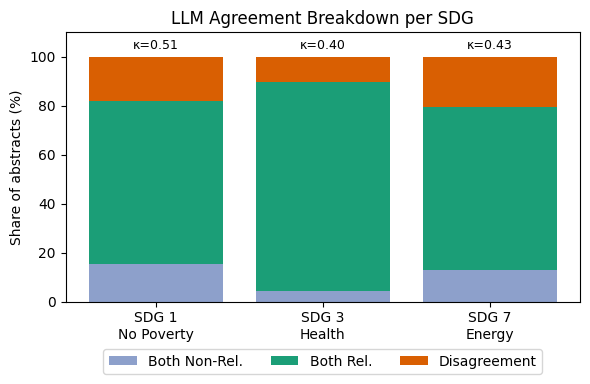

In [10]:
sdgs = ["SDG 1\nNo Poverty", "SDG 3\nHealth", "SDG 7\nEnergy"]
both_non = np.array([15.33, 4.33, 12.86])
both_rel = np.array([66.42, 85.30, 66.45])
disagree = np.array([18.25, 10.37, 20.69])
kappa = [0.506, 0.398, 0.428]

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#8da0cb", "#1b9e77", "#d95f02"]  # non-rel, rel, disagree

b1 = ax.bar(sdgs, both_non, color=colors[0], label="Both Non-Rel.")
b2 = ax.bar(sdgs, both_rel, bottom=both_non, color=colors[1], label="Both Rel.")
b3 = ax.bar(
    sdgs, disagree, bottom=both_non + both_rel, color=colors[2], label="Disagreement"
)

# κ annotations just above each bar
for x, k in zip(ax.get_xticks(), kappa):
    ax.text(x, 102, f"κ={k:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Share of abstracts (%)")
ax.set_ylim(0, 110)
ax.set_title("LLM Agreement Breakdown per SDG")
ax.legend(ncol=3, bbox_to_anchor=(0.5, -0.15), loc="upper center")
plt.tight_layout()
plt.show()

In [16]:
# ---------------------------------------------------------------------
# 1. Paths and file loading
# ---------------------------------------------------------------------
data_path = Path("/workspace/data/llmPredictions")


def load_and_clean(filepath):
    """
    Load a CSV file containing LLM-based SDG predictions and perform minimal cleaning.
    """
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["DOI"])
    df = df.drop_duplicates(subset="DOI", keep="first")
    return df


# Load SDG1 abstracts re-evaluated with SDG7 prompt
df_sdg1_llama = load_and_clean(data_path / "scopus-sdg1_prompts_7-llama3.1.csv")
df_sdg1_qwen = load_and_clean(data_path / "scopus_sdg1_prompts_7_qwen.csv")

# ---------------------------------------------------------------------
# 2. Drop unwanted columns
# ---------------------------------------------------------------------
drop_cols = ["Unnamed: 0.1", "Unnamed: 0"]
for df in [
    df_sdg1_qwen,
    df_sdg1_llama,
]:
    df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# ---------------------------------------------------------------------
# 3. Standardize column names
# ---------------------------------------------------------------------
rename_map = {
    "qwen-result": "qwen_result",
    "qwen_label": "model_label",
    "llama-3.1-result": "llama_result",
    "llama_label": "model_label",
}

for df in [
    df_sdg1_qwen,
    df_sdg1_llama,
]:
    df.rename(columns=rename_map, inplace=True)

# ---------------------------------------------------------------------
# 4. Add SDG + model identifiers
# ---------------------------------------------------------------------
df_sdg1_llama["SDG"] = "SDG7_prompt_on_SDG1"
df_sdg1_llama["Model"] = "Llama"
df_sdg1_qwen["SDG"] = "SDG7_prompt_on_SDG1"
df_sdg1_qwen["Model"] = "Qwen"

# ---------------------------------------------------------------------
# 5. Merge, clean, normalize
# ---------------------------------------------------------------------
df_all = pd.concat(
    [
        df_sdg1_qwen,
        df_sdg1_llama,
    ],
    ignore_index=True,
)

# Remove rows with missing DOIs or Abstracts
df_all = df_all.dropna(subset=["DOI"])
df_all = df_all.dropna(subset=["Abstract"])

# Normalize DOIs
df_all["DOI"] = df_all["DOI"].str.strip().str.lower()

# Reorder columns for better readability
df_all = df_all[
    [
        "DOI",
        "Abstract",
        "SDG",
        "Model",
        "model_label",
    ]
]

# ---------------------------------------------------------------------
# 6. Check consistency
# ---------------------------------------------------------------------
# Check for (DOI, Model, SDG) duplicates
dupe_groups = (
    df_all.groupby(["DOI", "Model", "SDG"])["model_label"].nunique().reset_index()
)

# Filter for inconsistent labeling (same input, different outputs)
inconsistent_labeling = dupe_groups[dupe_groups["model_label"] > 1]

print(f"Inconsistent (DOI, Model, SDG) labelings: {len(inconsistent_labeling)}")

# ---------------------------------------------------------------------
# 7. Pivot + agreement analysis
# ---------------------------------------------------------------------
# Pivot dataset to compare model labels for the same abstract
df_pivot = df_all.pivot_table(
    index=["DOI", "Abstract", "SDG"],
    columns="Model",
    values="model_label",
    aggfunc="first",
).reset_index()

# Flatten column index if needed
df_pivot.columns.name = None
df_pivot.columns = [str(col) for col in df_pivot.columns]

# Drop rows where either model is missing a label
df_pivot.dropna(subset=["Llama", "Qwen"], inplace=True)

# Compute agreement statistics
total_samples = len(df_pivot)
matching_labels = (df_pivot["Llama"] == df_pivot["Qwen"]).sum()
agreement_rate = matching_labels / total_samples
kappa_score = cohen_kappa_score(df_pivot["Llama"], df_pivot["Qwen"])

print(f"Total abstracts compared: {total_samples}")
print(f"Model agreement rate: {agreement_rate:.2%}")
print(f"Cohen’s Kappa Score: {kappa_score:.3f}")

# ---------------------------------------------------------------------
# 8. Breakdown by SDG
# ---------------------------------------------------------------------
for sdg in df_pivot["SDG"].unique():
    subset = df_pivot[df_pivot["SDG"] == sdg]
    total = len(subset)
    match = (subset["Llama"] == subset["Qwen"]).sum()
    kappa = cohen_kappa_score(subset["Llama"], subset["Qwen"])
    print(f"{sdg}: Agreement = {match / total:.2%}, Kappa = {kappa:.3f} (n={total})")


for sdg in df_pivot["SDG"].unique():
    subset = df_pivot[df_pivot["SDG"] == sdg]
    total = len(subset)
    match = (subset["Llama"] == subset["Qwen"]).sum()
    kappa = cohen_kappa_score(subset["Llama"], subset["Qwen"])

    both_rel = ((subset["Llama"] == "Relevant") & (subset["Qwen"] == "Relevant")).sum()
    both_nonrel = (
        (subset["Llama"] == "Non-Relevant") & (subset["Qwen"] == "Non-Relevant")
    ).sum()

    print(f"    Both Relevant: {both_rel} ({both_rel / total:.2%})")
    print(f"    Both Non-Relevant: {both_nonrel} ({both_nonrel / total:.2%})")
    print(f"    Disagreement: {total - match} ({(total - match) / total:.2%})")

Inconsistent (DOI, Model, SDG) labelings: 0
Total abstracts compared: 15133
Model agreement rate: 91.49%
Cohen’s Kappa Score: 0.586
SDG7_prompt_on_SDG1: Agreement = 91.49%, Kappa = 0.586 (n=15133)
    Both Relevant: 1118 (7.39%)
    Both Non-Relevant: 12727 (84.10%)
    Disagreement: 1288 (8.51%)
